<center> <font size=4> <b>Biophysical-Composite Segmentation Neural Model for Urban environment automatic 
classification</center>
<center> <font size=4> Author: Vargas-Zamudio Kevin Axel, PhD </center>
<center> <font size=2> email: seismo.ai.kevvargas@gmail.com </center>
<center> Project start date: 25/11/2025 </center>

* Auxiliar program for coordinates geometry computation for data retrieval on NIR, R, G composition and class label masks

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import shapely
from shapely.geometry import Polygon

In [47]:
def xy_polygon(x1,y1,x2,y2,x3,y3,x4,y4,geometry):
    px_res = geometry['px_res']
    npx_col = geometry['npx_col']
    npy_row = geometry['npy_row']

    theta1 = np.arctan((y2 - y1)/(x2 - x1)) #* 180.0 / np.pi
    theta2 = np.arctan((y4 - y1)/(x4 - x1))
    print('Theta:',theta1* 180.0 / np.pi,theta2* 180.0 / np.pi)
    
    npol_x = int((x2-x1)//px_res//npx_col)
    npol_y = int(np.abs(y1-y4)//px_res//npy_row)

    print(f'Number of polygons x,y: {npol_x, npol_y}')
    
    xpol = np.zeros((npol_y+1,npol_x+1),dtype = float)
    ypol = np.zeros((npol_y+1,npol_x+1),dtype = float)
    
    # Computation over n rows
    plt.figure(figsize=(5,5))
    for i in range(npol_y + 1):
        xi = x1 - (i*npy_row*px_res) * np.cos(theta2)
        yi = y1 - (i*npy_row*px_res) * np.sin(theta2)
        #print(i,i*npy_row*px_res, xi, yi)
        for j in range(npol_x + 1):
            xpol[i,j] = xi + (j*npx_col*px_res)*np.cos(theta1)
            ypol[i,j] = yi + (j*npx_col*px_res)*np.sin(theta1)
        plt.scatter(xpol[i,:],ypol[i,:],s=1)
            #print(j,j*npx_col*px_res)
    return xpol,ypol

In [19]:
# Landsat metadata 
L9_mtl = {'DATE':'2025-11-05',
          'X1' : 372600.000,  # UL
          'Y1' : 2193000.000, # UL
          'X2' : 600900.000,  # UR
          'Y2' : 2193000.000, # UR
          'X3' : 372600.000,  # LL
          'Y3' : 1960500.000, # LL
          'X4' : 600900.000,  # LR
          'Y4' : 1960500.000, # LR
          'REFLECTIVE_LINES' : 7751,
          'REFLECTIVE_SAMPLES' : 7611}

# Geometry parameters
geometry = {'npx_col':288,'npy_row':288,'px_res':30.0,'nbands':3}
npx_col = 256
npy_row = 256
px_res = 30.0 # meters
nbands = 3

#npol_x = L9_mtl['REFLECTIVE_SAMPLES'] // npx_col
#npol_y = L9_mtl['REFLECTIVE_LINES'] // npy_row


#print('Number of polygons (x,y)',npol_x, npol_y)

In [45]:
#def xy_polygon(x1,y1,x2,y2,x3,y3,x4,y4):
    npol_x = int((x2-x1)//px_res//npx_col)
    npol_y = int(np.abs(y1-y4)//px_res//npy_row)
    
    print(f'Number of polygons x,y: {npol_x, npol_y}')

    # Theta calculation
    theta1 = np.arctan((y2 - y1)/(x2 - x1)) #* 180.0 / np.pi
    theta2 = np.arctan((y4 - y1)/(x4 - x1))

    print('Theta:',theta1* 180.0 / np.pi,theta2* 180.0 / np.pi)
    
    print(f'Angulos direccion: {theta1,theta2}')
    xpol = np.zeros((1,npol_x+1),dtype = float)
    ypol = np.zeros((1,npol_x+1),dtype = float)
    
    # Computation over 1 row
    for j in range(npol_x + 1):
        xpol[0,j] = x1 + (j*npx_col*px_res)*np.cos(theta1)
        ypol[0,j] = y1 + (j*npx_col*px_res)*np.sin(theta1)
        #print(j,j*npx_col*px_res)
        
    plt.scatter(xpol,ypol)

    return xpol,ypol

IndentationError: unexpected indent (391499555.py, line 2)

In [74]:
xpol[8,:]

array([402027.5979929 , 409534.20157419, 417040.80515548, 424547.40873677,
       432054.01231807, 439560.61589936, 447067.21948065, 454573.82306194,
       462080.42664324, 469587.03022453, 477093.63380582, 484600.23738711,
       492106.84096841, 499613.4445497 , 507120.04813099, 514626.65171228,
       522133.25529357, 529639.85887487, 537146.46245616, 544653.06603745,
       552159.66961874, 559666.27320004, 567172.87678133, 574679.48036262,
       582186.08394391])

In [63]:
xpol[-2,:]

array([630735.29083741, 638415.29050467, 646095.29017193, 653775.28983919,
       661455.28950644, 669135.2891737 , 676815.28884096, 684495.28850822,
       692175.28817548, 699855.28784273, 707535.28750999])

In [62]:
print(xpol.shape,ypol.shape)

(9, 11) (9, 11)


In [26]:
def polygon_vertices(x1,y1,x2,y2,x3,y3,x4,y4):
    coords = [(x1,y1),(x2,y2),(x3,y3),(x4,y4)]
    return Polygon(coords)

In [27]:
def polygon_vertices(row):
    coords = [(row['x1'],row['y1']),(row['x2'],row['y2']),(row['x3'],row['y3']),(row['x4'],row['y4'])]
    return Polygon(coords)

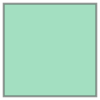

In [121]:
polygon_vertices(0,0,0,1,1,1,1,0)

In [88]:
# Crear dataframe con columnas = x1, y1, x2, y2,...
def create_polygon_geoDF(xpol,ypol):
    row = np.zeros(((xpol.shape[0]-1)*(ypol.shape[1]-1),8),dtype=float)
    
    cols = ['x1','y1','x2','y2','x3','y3','x4','y4']
    
    for j in range(xpol.shape[1]-1): # Rows
        for i in range(xpol.shape[0]-1): # cols
            #print(i,j)
            row[j*(xpol.shape[0]-1)+i,:] = np.array([xpol[i,j],ypol[i,j],xpol[i,j+1],ypol[i,j+1],
                             xpol[i+1,j+1],ypol[i+1,j+1],xpol[i+1,j],ypol[i+1,j]])
    data = pd.DataFrame(row,columns=cols)

    return data

In [84]:
xpol.shape

(9, 11)

In [85]:
xpol.shape[0]-1

8

In [92]:
# Polygon object column creation and added to data frame
def create_mosaic_shape(xpol,ypol,data,flag,CRS):
    for j in range(xpol.shape[1]-1): # Rows
        for i in range(xpol.shape[0]-1): # cols
            #print([i,j],[i,j+1],[i+1,j+1],[i+1,j])
            data['geometry'] = data.apply(polygon_vertices,axis=1)
    
    # Geodataframe definition with polygon information
    gdf = gpd.GeoDataFrame(data, crs = CRS)
    gdf.to_file(f'Mosaic_polygons_extraction_{flag}.shp')

Theta: -12.19825191569595 77.55219758083575
Number of polygons x,y: (24, 24)
(25, 25) (25, 25)
0 0
1 0
2 0
3 0
4 0
5 0
6 0
7 0
8 0
9 0
10 0
11 0
12 0
13 0
14 0
15 0
16 0
17 0
18 0
19 0
20 0
21 0
22 0
23 0
0 1
1 1
2 1
3 1
4 1
5 1
6 1
7 1
8 1
9 1
10 1
11 1
12 1
13 1
14 1
15 1
16 1
17 1
18 1
19 1
20 1
21 1
22 1
23 1
0 2
1 2
2 2
3 2
4 2
5 2
6 2
7 2
8 2
9 2
10 2
11 2
12 2
13 2
14 2
15 2
16 2
17 2
18 2
19 2
20 2
21 2
22 2
23 2
0 3
1 3
2 3
3 3
4 3
5 3
6 3
7 3
8 3
9 3
10 3
11 3
12 3
13 3
14 3
15 3
16 3
17 3
18 3
19 3
20 3
21 3
22 3
23 3
0 4
1 4
2 4
3 4
4 4
5 4
6 4
7 4
8 4
9 4
10 4
11 4
12 4
13 4
14 4
15 4
16 4
17 4
18 4
19 4
20 4
21 4
22 4
23 4
0 5
1 5
2 5
3 5
4 5
5 5
6 5
7 5
8 5
9 5
10 5
11 5
12 5
13 5
14 5
15 5
16 5
17 5
18 5
19 5
20 5
21 5
22 5
23 5
0 6
1 6
2 6
3 6
4 6
5 6
6 6
7 6
8 6
9 6
10 6
11 6
12 6
13 6
14 6
15 6
16 6
17 6
18 6
19 6
20 6
21 6
22 6
23 6
0 7
1 7
2 7
3 7
4 7
5 7
6 7
7 7
8 7
9 7
10 7
11 7
12 7
13 7
14 7
15 7
16 7
17 7
18 7
19 7
20 7
21 7
22 7
23 7
0 8
1 8
2 8
3 8
4 8
5 8
6

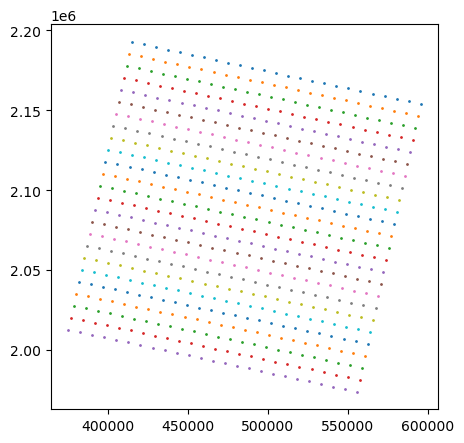

In [87]:
# Main program for creating mosaic shape for raster extraction INPUT DATA 

# Upper, lower, right and left coordinates
x1 , y1 = 415270.9961, 2192827.1139
x2 , y2 = 600030.5636, 2152886.5819
x3 , y3 = 558099.4862, 1960816.6655
x4 , y4 = 373029.8289, 2001464.6649

# Geometry parameters
geometry = {'npx_col':256,'npy_row':256,'px_res':30.0,'nbands':3,'crs':'EPSG:32614'}
#npx_col = 256
#npy_row = 256
#px_res = 30.0 # meters
#nbands = 3

xpol,ypol = xy_polygon(x1,y1,x2,y2,x3,y3,x4,y4,geometry)
print(xpol.shape,ypol.shape)

data = create_polygon_geoDF(xpol,ypol)
data.head(5)

flag = 'Input_data'
create_mosaic_shape(xpol,ypol,data,flag,geometry['CRS'])

Theta: 0.016865961028268723 89.99817842628937
Number of polygons x,y: (10, 8)
(9, 11) (9, 11)
              x1            y1             x2            y2             x3  \
0  630737.000000  2.313012e+06  638416.999667  2.313014e+06  638416.755501   
1  630736.755834  2.305332e+06  638416.755501  2.305334e+06  638416.511335   
2  630736.511668  2.297652e+06  638416.511335  2.297654e+06  638416.267169   
3  630736.267502  2.289972e+06  638416.267169  2.289974e+06  638416.023003   
4  630736.023336  2.282292e+06  638416.023003  2.282294e+06  638415.778837   

             y3             x4            y4  
0  2.305334e+06  630736.755834  2.305332e+06  
1  2.297654e+06  630736.511668  2.297652e+06  
2  2.289974e+06  630736.267502  2.289972e+06  
3  2.282294e+06  630736.023336  2.282292e+06  
4  2.274614e+06  630735.779170  2.274612e+06  


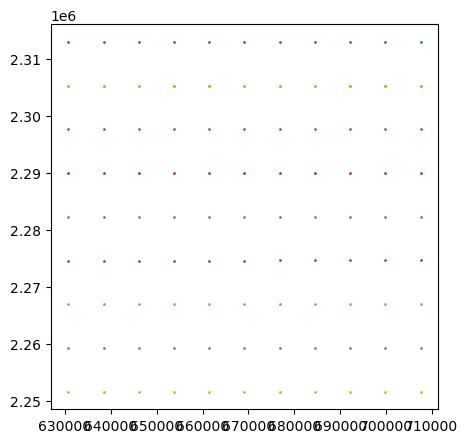

In [93]:
# Main program for creating mosaic shape for raster extraction GENERALIZATION DATA

# Upper, lower, right and left coordinates
x1 , y1 = 630737, 2313012
x2 , y2 = 712268, 2313036
x3 , y3 = 712266, 2250084
x4 , y4 = 630735, 2250104

# Geometry parameters
geometry = {'npx_col':256,'npy_row':256,'px_res':30.0,'nbands':3,'CRS':'EPSG:32613'}
xpol,ypol = xy_polygon(x1,y1,x2,y2,x3,y3,x4,y4,geometry)
print(xpol.shape,ypol.shape)

data = create_polygon_geoDF(xpol,ypol)
print(data.head(5))

flag = 'Gen_data'
create_mosaic_shape(xpol,ypol,data,flag,geometry['CRS'])